# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [3]:
# Завдання 1а — створіть масив і обчисліть статистику
np.random.seed(42)
sample = np.random.normal(loc=0.0, scale=1.0, size=10_000)

mean_val = np.mean(sample)
std_val = np.std(sample)
min_val = np.min(sample)
max_val = np.max(sample)

print(f"mean={mean_val:.5f}, std={std_val:.5f}, min={min_val:.5f}, max={max_val:.5f}")

mean=-0.00214, std=1.00341, min=-3.92240, max=3.92624


In [4]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
lower = mean_val - 2 * std_val
upper = mean_val + 2 * std_val

outliers_mask = (sample < lower) | (sample > upper)
outliers_count = np.sum(outliers_mask)
outliers_percent = outliers_count / sample.size * 100

print(f"outliers={outliers_count} ({outliers_percent:.2f}%)")


outliers=462 (4.62%)


**Ваша відповідь (б):** Отримана частка близька до теоретичних ~4.55, але є трохи більшою, а саме 4.62, що узгоджується з нормальним розподілом.


---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [5]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
# 2-і) Скільки рядків і стовпців?
rows, cols = sales.shape
print(f"rows={rows}, cols={cols}")


rows=21613, cols=21


In [7]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
price_stats = sales["price"].agg(["min", "max", "mean", "median"])
price_stats


min       7.500000e+04
max       7.700000e+06
mean      5.400881e+05
median    4.500000e+05
Name: price, dtype: float64

In [8]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
zip_unique = sales["zipcode"].nunique()
zip_counts = sales["zipcode"].value_counts()
top_zip = zip_counts.idxmax()
top_zip_count = zip_counts.max()

print(f"unique_zipcodes={zip_unique}")
print(f"top_zipcode={top_zip} ({top_zip_count} listings)")


unique_zipcodes=70
top_zipcode=98103 (602 listings)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

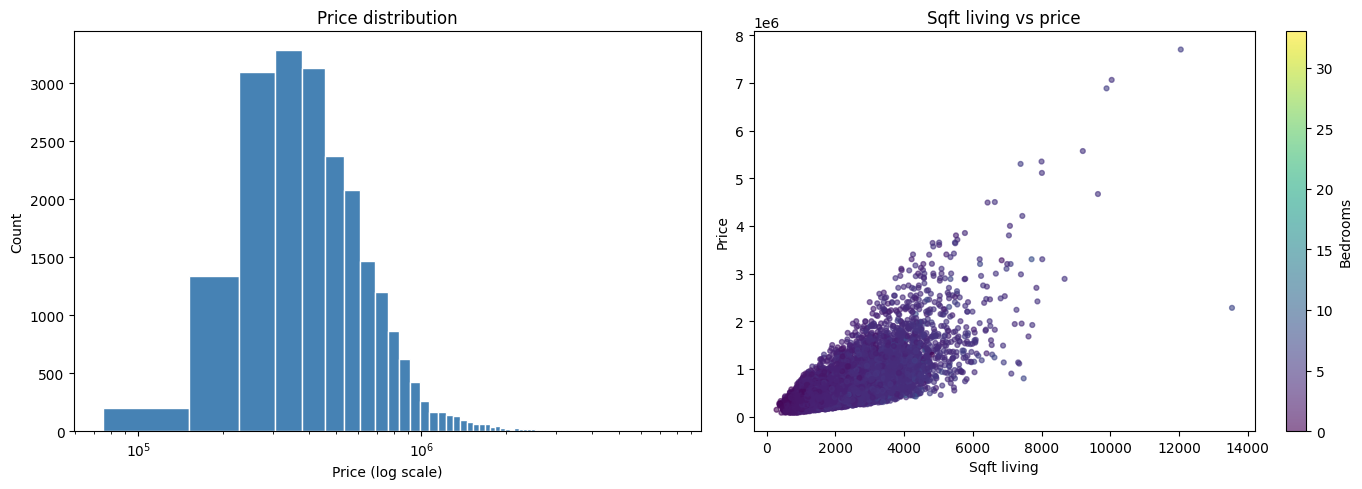

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(sales["price"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_xlabel("Price (log scale)")
axes[0].set_ylabel("Count")
axes[0].set_title("Price distribution")

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
bed_min = sales["bedrooms"].min()
bed_max = sales["bedrooms"].max()
scatter = axes[1].scatter(
    sales["sqft_living"],
    sales["price"],
    c=sales["bedrooms"],
    cmap="viridis",
    alpha=0.6,
    s=12,
    vmin=bed_min,
    vmax=bed_max,
)
axes[1].set_xlabel("Sqft living")
axes[1].set_ylabel("Price")
axes[1].set_title("Sqft living vs price")
colorbar = fig.colorbar(scatter, ax=axes[1])
colorbar.set_label("Bedrooms")

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Розподіл цін різко правосторонньо-скошений: більшість угод у нижчому діапазоні, а дорогі будинки утворюють довгий хвіст (логшкала це підкреслює).

**Спостереження (правий графік):** Ціна загалом зростає зі збільшенням житлової площі, а більша кількість спалень частіше відповідає більшим площам і вищим цінам.


---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [10]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [11]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
X_train = train_data[["sqft_living"]]
y_train = train_data["price"]
X_test = test_data[["sqft_living"]]
y_test = test_data["price"]

model1 = LinearRegression()
model1.fit(X_train, y_train)

intercept = model1.intercept_
coef = model1.coef_[0]

preds = model1.predict(X_test)
mse_model1 = mean_squared_error(y_test, preds)
rmse_model1 = np.sqrt(mse_model1)

price_2500 = model1.predict(pd.DataFrame({"sqft_living": [2500]}))[0]

print(f"intercept={intercept:.2f}")
print(f"coef_sqft_living={coef:.2f}")
print(f"MSE={mse_model1:.2f}")
print(f"RMSE={rmse_model1:.2f}")
print(f"predicted_price_2500sqft={price_2500:.2f}")


intercept=-41999.19
coef_sqft_living=279.55
MSE=76484977061.78
RMSE=276559.17
predicted_price_2500sqft=656887.76


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [12]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
features = ["sqft_living", "bedrooms", "bathrooms", "yr_built"]
X_train2 = train_data[features]
y_train2 = train_data["price"]
X_test2 = test_data[features]
y_test2 = test_data["price"]

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

preds2 = model2.predict(X_test2)
mse_model2 = mean_squared_error(y_test2, preds2)
rmse_model2 = np.sqrt(mse_model2)

print(f"RMSE_model1={rmse_model1:.2f}")
print(f"RMSE_model2={rmse_model2:.2f}")


RMSE_model1=276559.17
RMSE_model2=262985.98


**Відповідь:** RMSE у Моделі 2 нижчий, бо додаткові ознаки дають моделі більше інформації про ціну.


---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

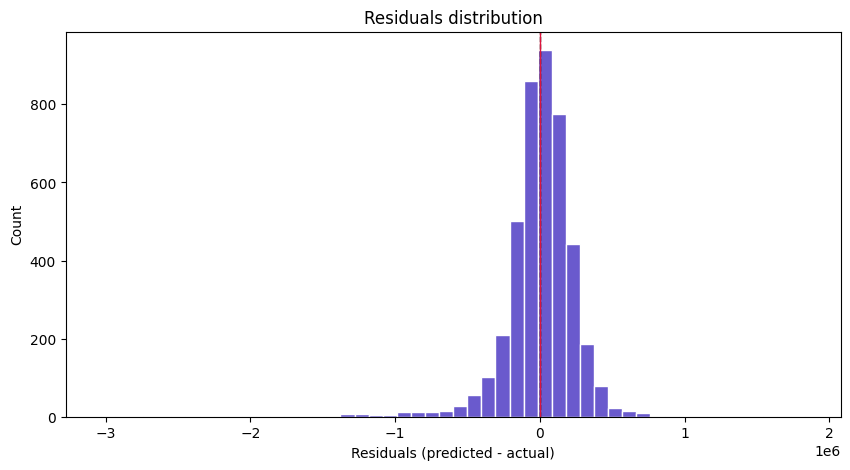

mean_residual=-1611.51


In [13]:
# Бонус — аналіз залишків
try:
    model_for_residuals = model2
    X_test_residuals = X_test2
    y_test_residuals = y_test2
    preds_residuals = preds2
except NameError:
    features = ["sqft_living", "bedrooms", "bathrooms", "yr_built"]
    X_train2 = train_data[features]
    y_train2 = train_data["price"]
    X_test_residuals = test_data[features]
    y_test_residuals = test_data["price"]

    model_for_residuals = LinearRegression()
    model_for_residuals.fit(X_train2, y_train2)
    preds_residuals = model_for_residuals.predict(X_test_residuals)

residuals = preds_residuals - y_test_residuals
mean_residual = np.mean(residuals)

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color="slateblue", edgecolor="white")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(mean_residual, color="crimson", linestyle="-", linewidth=1)
plt.xlabel("Residuals (predicted - actual)")
plt.ylabel("Count")
plt.title("Residuals distribution")
plt.show()

print(f"mean_residual={mean_residual:.2f}")


**Спостереження:** Гістограма 'доволі' симетрична проте середній залишок нижчий за нуль на 1611.51. Ненульовий середній залишок означає, що модель регулярно завищує або занижує прогнози. В нашому випадку модель має зміщення і в середньому недооціює вартість житла на 1612 футнів. 
